In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('/content/netflix_titles.csv')
df = df.dropna(subset=['country'])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


,title
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


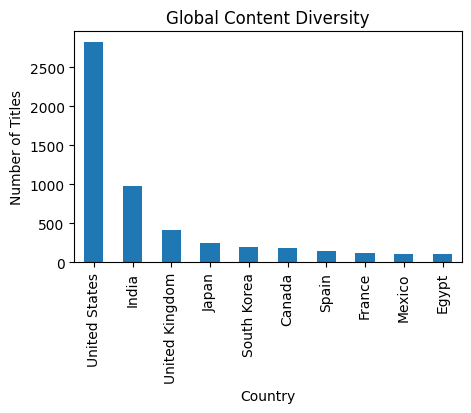

In [119]:
top_countries = pd.DataFrame(df.groupby('country').title.count().sort_values(ascending=False).head(10))
total_titles = df.title.count()
top_countries.plot(
    kind='bar',
    legend=False,
    ylabel='Number of Titles',
    xlabel='Country',
    figsize=(5,3),
    title = 'Global Content Diversity'
)

,title
release_year,
2012,11
2013,30
2014,30
2015,65
2016,130
2017,162
2018,113
2019,94
2020,66


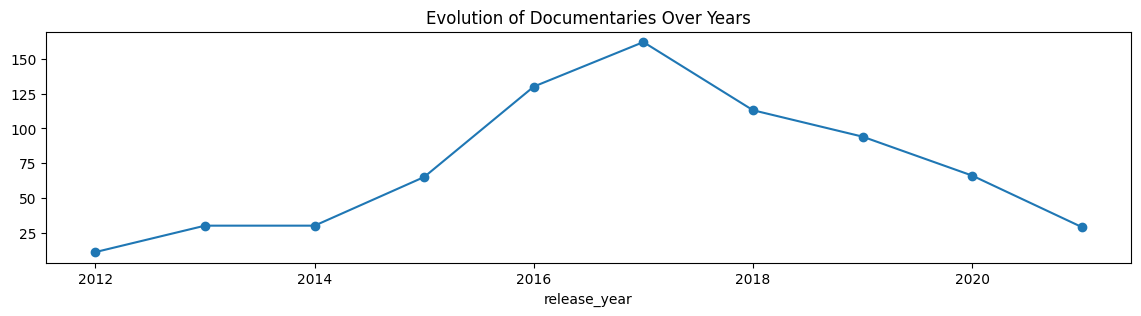

In [120]:
Documentaries =  df[df['listed_in'].str.contains('Documentaries', na=False)]
evolution_of_Documentaries = Documentaries.groupby('release_year').title.count().tail(10)
evolution_of_Documentaries.plot(kind='line', marker='o', title='Evolution of Documentaries Over Years', figsize=(14,3))

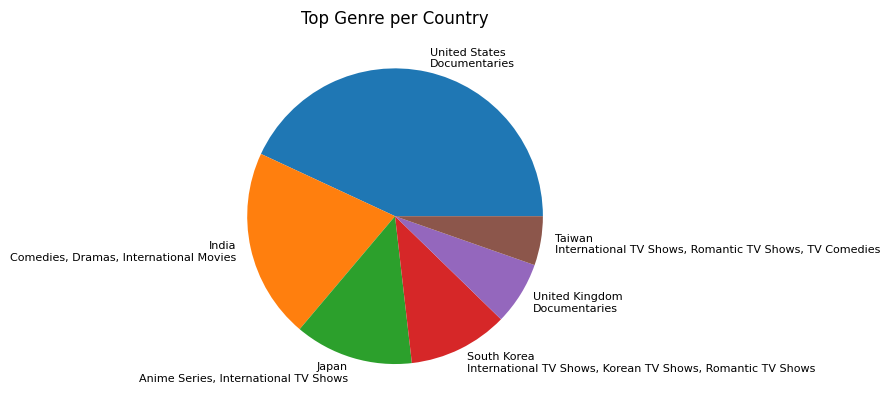

,country,listed_in,count
2153,United States,Documentaries,249
810,India,"Comedies, Dramas, International Movies",120
1050,Japan,"Anime Series, International TV Shows",75
1465,South Korea,"International TV Shows, Korean TV Shows, Roman...",63
1772,United Kingdom,Documentaries,40
1613,Taiwan,"International TV Shows, Romantic TV Shows, TV ...",31


In [121]:
genres = df.groupby(['country', 'listed_in']).size().reset_index(name='count')
top_genres = pd.DataFrame(genres.sort_values(by = 'count',ascending=False).drop_duplicates('country')).head(6)
labels = [f"{country}\n{genre}" for country, genre in zip(top_genres['country'], top_genres['listed_in'])]
plt.pie(
    top_genres['count'],
    labels=labels,
    textprops={'fontsize': 8}
)
plt.title('Top Genre per Country')
plt.show()
top_genres

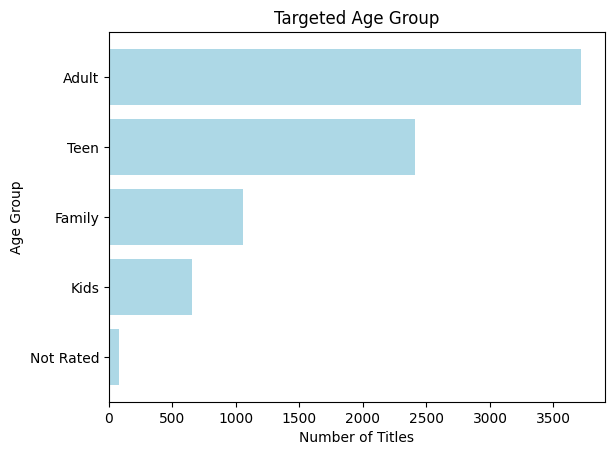

,age_group
age_group,
Adult,3719
Teen,2412
Family,1054
Kids,653
Not Rated,80


In [123]:
age_group_mapping = {'TV-MA': 'Adult','R': 'Adult','TV-14': 'Teen','PG-13': 'Teen','TV-PG': 'Family','PG': 'Family','TV-Y7': 'Kids','TV-Y': 'Kids','TV-G': 'Kids',
    'NR': 'Not Rated'}
df['age_group'] = df['rating'].map(age_group_mapping)
targetted_age_group = df.groupby('age_group').age_group.count().sort_values(ascending=False).head(10)
plt.barh(targetted_age_group.index, targetted_age_group.values, color='lightblue')
plt.xlabel('Number of Titles')
plt.ylabel('Age Group')
plt.title('Targeted Age Group')
plt.gca().invert_yaxis()
plt.show()

,listed_in
listed_in,
"Action & Adventure, Classic Movies, International Movies",1
"TV Action & Adventure, TV Dramas, Teen TV Shows",1
"Action & Adventure, Cult Movies, Dramas",1
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Sports Movies",1


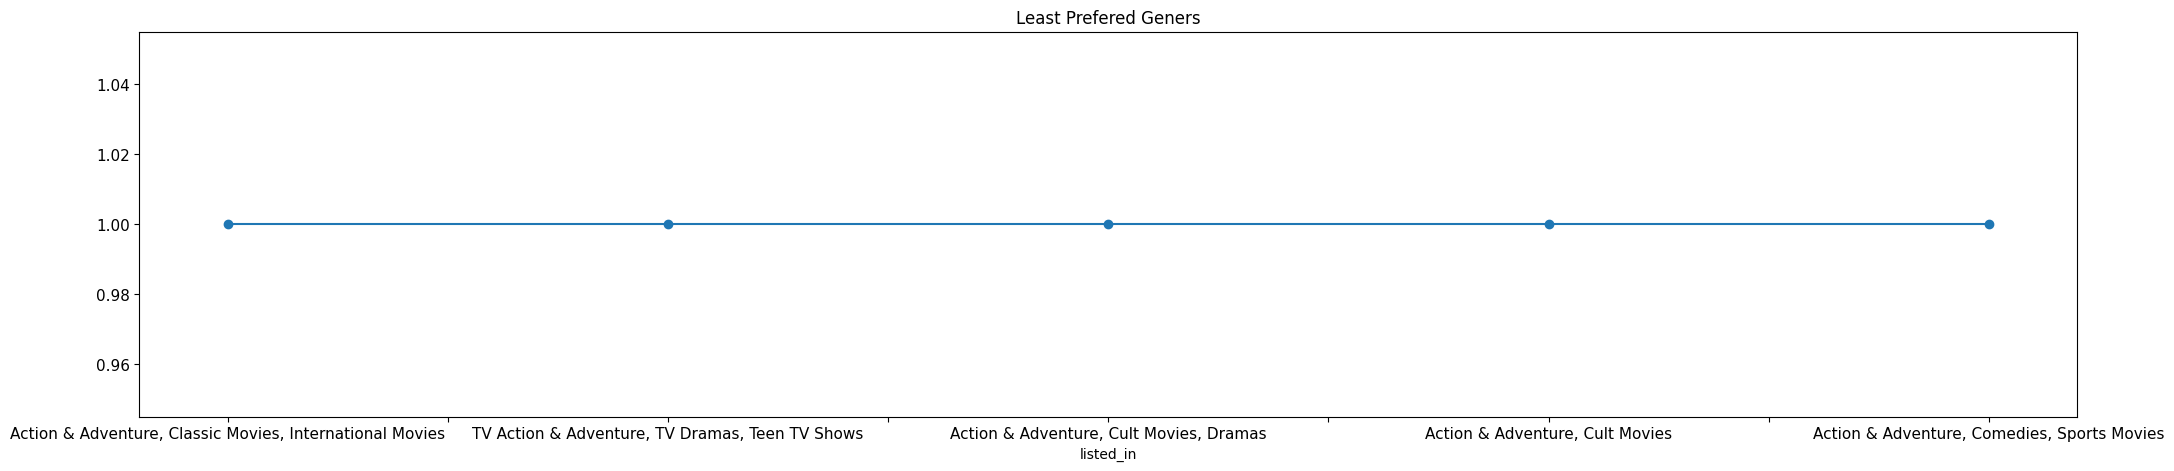

In [124]:
least_geners = df.groupby('listed_in').listed_in.count().sort_values().head(5)
least_geners.plot(kind='line', marker='o', title='Least Prefered Geners', figsize=(25,5), fontsize=11)
least_geners